# Orthogonal Re-Basin - LeNet

Agnese Pallaria - matricola,1987001
---

## Struttura

| # | Sezione |
|---|---|
| 1 | Dataset e Architettura |
| 2 | Training di due modelli indipendenti |
| 3 | CKA - quanto sono già simili funzionalmente? |
| 4 | Allineamento Ortogonale |
| 5 | Alignment error |
| 6 | ReLU misalignment e sign flip |
| 7 | Cycle-consistency |
| 8 | Applicazione Q ai pesi: cosa succede all'accuracy? |
| 9 | Loss barrier: LERP e SLERP |
| 10 | PCA dello spazio latente |
| 11 | Tabella riassuntiva|

##1. Dataset e Architettura

INSTALL

In [48]:
# Installiamo la libreria PyTorch Lightning
# PyTorch Lightning è un framework che semplifica
# l'addestramento dei modelli PyTorch
!pip install pytorch-lightning -q

# Installiamo la libreria SciPy
# SciPy è utile per operazioni scientifiche e matematiche avanzate,
# come l'ottimizzazione e l'integrazione
!pip install scipy -q

# Installiamo la libreria scikit-learn
# Scikit-learn è una libreria fondamentale per machine learning,
# data preprocessing e modelli predittivi
!pip install scikit-learn -q

IMPORT

In [49]:
# Importiamo PyTorch, la libreria principale per il deep learning
import torch
import torch.nn as nn  # Per costruire modelli neurali usando moduli predefiniti
import torch.nn.functional as F  # Per funzioni di attivazione e operazioni sui tensori
from torch.utils.data import DataLoader  # Per gestire dataset e batch in modo efficiente

# Importiamo torchvision per dataset standard e trasformazioni sulle immagini
import torchvision
import torchvision.transforms as transforms  # Per trasformazioni come normalizzazione e resizing

# Importiamo PyTorch Lightning, che semplifica il training dei modelli PyTorch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
# - ModelCheckpoint: salva il modello durante il training
# - EarlyStopping: ferma il training se la performance smette di migliorare

# Importiamo librerie utili per calcoli numerici e visualizzazione
import numpy as np  # Per operazioni numeriche avanzate su array
import matplotlib.pyplot as plt  # Per creare grafici e visualizzare immagini

# Importiamo strumenti avanzati da SciPy e scikit-learn
from sklearn.decomposition import PCA  # Per riduzione dimensionale con Principal Component Analysis
from scipy.linalg import svd as scipy_svd  # Per decomposizione ai valori singolari
from scipy.optimize import linear_sum_assignment  # Per risolvere problemi di assegnazione (Hungarian algorithm)

# Importiamo librerie standard per gestione file e copie di oggetti
import copy, os

In [50]:
# Creiamo una cartella per salvare esperimenti se non esiste già
os.makedirs("./experiments_lenet", exist_ok=True)

# Stampiamo le versioni di PyTorch e PyTorch Lightning per riferimento
print("=" * 40)
print(f"  PyTorch   : {torch.__version__}")
print(f"  Lightning : {pl.__version__}")
print("=" * 40)

  PyTorch   : 2.10.0+cpu
  Lightning : 2.6.1


DATASET

In [51]:
# Trasformazione base: immagini PIL → tensori
transform = transforms.ToTensor()

# Dataset CIFAR-10
train_full = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=transform)
test_full  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# DataLoader
train_loader = DataLoader(train_full, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_full,  batch_size=128, shuffle=False, num_workers=2)

In [52]:
# Classi e info dataset
CLASSES = train_full.classes
print(f"Train: {len(train_full):,} immagini")
print(f"Test : {len(test_full):,} immagini")
print(f"Classi: {CLASSES}")

Train: 50,000 immagini
Test : 10,000 immagini
Classi: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


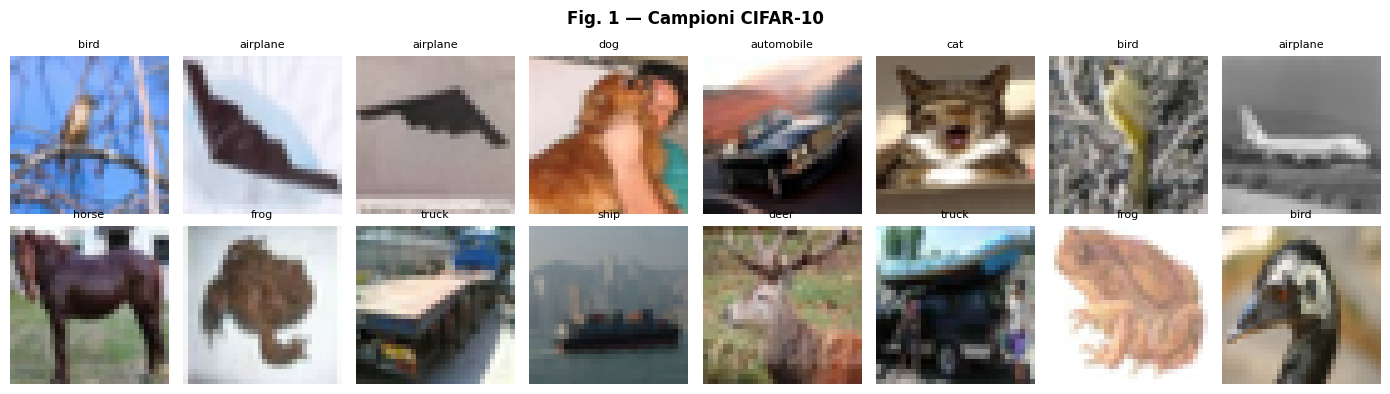

In [53]:
# Prendiamo un batch casuale di 16 immagini dal dataset di training
imgs, labels = next(iter(DataLoader(train_full, batch_size=16, shuffle=True)))

# Creiamo una griglia 2x8 per visualizzare le immagini
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

# Visualizziamo ogni immagine con la sua classe
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].permute(1, 2, 0).numpy().clip(0,1))  # Cambiamo ordine canali e limiti [0,1]
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis("off")

plt.suptitle("Fig. 1 — Campioni CIFAR-10", fontweight="bold")
plt.tight_layout()
plt.show()

ARCHITETTURA LeNet

In [54]:
class LeNetCIFAR(nn.Module):
    """
    LeNet adattata a CIFAR-10.
    Il layer fc1 (256 neuroni) è il nostro spazio latente:
    è qui che confrontiamo le rappresentazioni interne dei due modelli
    e calcoliamo tutte le trasformazioni ortogonali.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.pool  = nn.AvgPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 6 * 6, 256)  # ← spazio latente
        self.fc2   = nn.Linear(256, 128)
        self.fc3   = nn.Linear(128, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

    def get_latent(self, x):
        """Attivazioni POST-ReLU di fc1."""
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.relu(self.fc1(x))

    def get_pre_relu(self, x):
        """Attivazioni PRE-ReLU di fc1 — per il sign flip."""
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc1(x)

dummy = torch.randn(4, 3, 32, 32)
net_t = LeNetCIFAR()
print("LeNet CIFAR-10:")
print(f"  Output : {net_t(dummy).shape}")
print(f"  Latent : {net_t.get_latent(dummy).shape}  ← spazio 256-dim")
print(f"  Params : {sum(p.numel() for p in net_t.parameters()):,}")

LeNet CIFAR-10:
  Output : torch.Size([4, 10])
  Latent : torch.Size([4, 256])  ← spazio 256-dim
  Params : 677,962


In [55]:
print("Ho scelto fc1 come spazio latente perché la dimensione di 256 è abbastanza grande")
print("da offrire una rappresentazione significativa dei dati, senza diventare troppo complessa")
print("da rendere computazionalmente onerosa la decomposizione SVD (specialmente per spazi più grandi).")

Ho scelto fc1 come spazio latente perché la dimensione di 256 è abbastanza grande
da offrire una rappresentazione significativa dei dati, senza diventare troppo complessa
da rendere computazionalmente onerosa la decomposizione SVD (specialmente per spazi più grandi).


##2. Training di due modelli indipendenti

TRAINING

In [56]:
# Definizione del modulo Lightning per LeNet su CIFAR-10 e funzione di training:
# - LeNetModule: wrapper Lightning con forward, loss, training/validation step, ottimizzatore e scheduler
# - train_model: gestisce seed, checkpoint, early stopping, trainer e ritorna il modello migliore
class LeNetModule(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.model     = LeNetCIFAR()
        self.lr        = lr
        self.criterion = nn.CrossEntropyLoss()
        self.save_hyperparameters()

    def forward(self, x):      return self.model(x)
    def get_latent(self, x):   return self.model.get_latent(x)
    def get_pre_relu(self, x): return self.model.get_pre_relu(x)

    def training_step(self, batch, _):
        imgs, labels = batch
        loss = self.criterion(self(imgs), labels)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        imgs, labels = batch
        out  = self(imgs)
        loss = self.criterion(out, labels)
        acc  = (out.argmax(1) == labels).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc",  acc,  prog_bar=True)

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15)
        return [opt], [sch]


def train_model(seed, name, dirpath="./experiments_lenet"):
    print(f"\nTraining {name} — seed={seed}")
    torch.manual_seed(seed)
    ckpt    = ModelCheckpoint(dirpath=dirpath,
                              filename=name,
                              monitor="val_acc",
                              mode="max",
                              save_top_k=1)
    es      = EarlyStopping(monitor="val_acc",
                            patience=5,
                            mode="max")
    trainer = pl.Trainer(max_epochs=15,
                         callbacks=[ckpt, es],
                         enable_progress_bar=True,
                         logger=False,
                         accelerator="cpu")
    module  = LeNetModule()
    trainer.fit(module, train_loader, test_loader)
    best    = LeNetModule.load_from_checkpoint(ckpt.best_model_path)
    print(f"  Best val_acc: {ckpt.best_model_score.item():.4f}")
    return best

In [57]:
module_A = train_model(seed=42, name="lenet_A")
net_A    = module_A.model

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training lenet_A — seed=42


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/experiments_lenet exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ LeNetCIFAR       │  677 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 677 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 677 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


  Best val_acc: 0.7229


In [58]:
module_B = train_model(seed=99, name="lenet_B")
net_B    = module_B.model

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training lenet_B — seed=99


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ LeNetCIFAR       │  677 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 677 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 677 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


  Best val_acc: 0.6988


In [59]:
# Funzione di valutazione del modello su un DataLoader e confronto tra due modelli:
# - evaluate: calcola loss e accuratezza sul dataset fornito
# - confronto modelli A e B: stampa accuracy, loss, gap e correlazione dei pesi del primo layer fully connected
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    crit = nn.CrossEntropyLoss()
    tot_loss, correct, n = 0., 0, 0
    for imgs, labels in loader:
        out       = model(imgs)
        tot_loss += crit(out, labels).item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        n        += imgs.size(0)
    return tot_loss / n, correct / n

loss_A, acc_A = evaluate(net_A, test_loader)
loss_B, acc_B = evaluate(net_B, test_loader)

print("=" * 45)
print(f"  Model A (seed=42): acc={acc_A:.4f}  loss={loss_A:.4f}")
print(f"  Model B (seed=99): acc={acc_B:.4f}  loss={loss_B:.4f}")
print(f"  Gap accuracy     : {abs(acc_A-acc_B):.4f}")

# Correlazione tra pesi del layer fc1 dei due modelli
w_corr = np.corrcoef(
    net_A.fc1.weight.data.numpy().flatten(),
    net_B.fc1.weight.data.numpy().flatten())[0,1]
print(f"  Correlazione pesi fc1: {w_corr:.4f}")
print("=" * 45)

  Model A (seed=42): acc=0.7229  loss=0.8568
  Model B (seed=99): acc=0.6988  loss=0.9171
  Gap accuracy     : 0.0241
  Correlazione pesi fc1: 0.0016


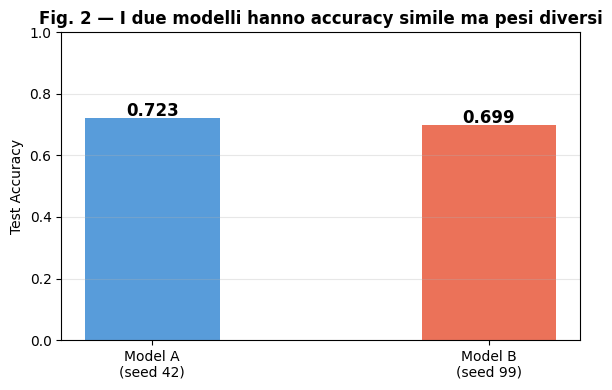

In [60]:
# Visualizzazione comparativa delle accuracy dei due modelli:
# - barre per Model A e Model B
# - valori sopra le barre e titolo descrittivo
# - evidenzia similarità in performance nonostante differenze nei pesi
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Model A\n(seed 42)", "Model B\n(seed 99)"],
              [acc_A, acc_B], color=["#3B8BD4","#E8593C"], alpha=0.85, width=0.4)

for b, v in zip(bars, [acc_A, acc_B]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f"{v:.3f}", ha="center", fontweight="bold", fontsize=12)

ax.set_ylim(0, 1)
ax.set_ylabel("Test Accuracy")
ax.set_title("Fig. 2 — I due modelli hanno accuracy simile ma pesi diversi",
             fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
print(f"\nAccuracy simile ({acc_A:.3f} vs {acc_B:.3f}), ma la correlazione tra i pesi è quasi zero ({w_corr:.4f}).")
print("Questo suggerisce che, nonostante il comportamento simile dei modelli, le loro rappresentazioni interne sono molto diverse.")
print("Questo è un esempio di ciò che avviene nel Git Re-Basin, dove i modelli convergono verso soluzioni simili in termini di output,")
print("ma le loro strutture interne possono essere diverse a causa di permutazioni nei pesi.")


Accuracy simile (0.723 vs 0.699), ma la correlazione tra i pesi è quasi zero (0.0016).
Questo suggerisce che, nonostante il comportamento simile dei modelli, le loro rappresentazioni interne sono molto diverse.
Questo è un esempio di ciò che avviene nel Git Re-Basin, dove i modelli convergono verso soluzioni simili in termini di output,
ma le loro strutture interne possono essere diverse a causa di permutazioni nei pesi.


##3. CKA layer-by-layer

In [62]:
# Calcolo della similarità tra layer dei due modelli usando CKA (Centered Kernel Alignment):
# - linear_cka: misura similarità lineare tra matrici di attivazioni
# - get_hook_acts: raccoglie le attivazioni di un layer su tutto il dataset
# - layer_pairs: coppie di layer corrispondenti di net_A e net_B
# - stampa i punteggi CKA con note qualitativa (alta, media, bassa)
def linear_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    hsic  = np.linalg.norm(X.T @ Y, "fro") ** 2
    normX = np.linalg.norm(X.T @ X, "fro")
    normY = np.linalg.norm(Y.T @ Y, "fro")
    return hsic / (normX * normY + 1e-8)

def get_hook_acts(model, loader, layer):
    acts = []
    h    = layer.register_forward_hook(
               lambda m,i,o: acts.append(o.detach().cpu()))
    model.eval()
    with torch.no_grad():
        for imgs,_ in loader:
            model(imgs)
    h.remove()
    out = torch.cat(acts, dim=0)
    return out.view(out.size(0), -1).numpy()

layer_pairs = [
    ("conv1", net_A.conv1, net_B.conv1),
    ("conv2", net_A.conv2, net_B.conv2),
    ("fc1",   net_A.fc1,   net_B.fc1),
    ("fc2",   net_A.fc2,   net_B.fc2),
    ("fc3",   net_A.fc3,   net_B.fc3),
]

print("Calcolo CKA per ogni layer...")
cka_scores = {}
print("=" * 48)
print(f"  {'Layer':<8} {'CKA':>8}  {'Note'}")
print("=" * 48)
for name, lA, lB in layer_pairs:
    s = linear_cka(
        get_hook_acts(net_A, test_loader, lA),
        get_hook_acts(net_B, test_loader, lB))
    cka_scores[name] = s
    note = "alta" if s > 0.7 else ("media" if s > 0.4 else "bassa")
    print(f"  {name:<8} {s:>8.4f}  similarità {note}")
print("=" * 48)

Calcolo CKA per ogni layer...
  Layer         CKA  Note
  conv1      0.9798  similarità alta
  conv2      0.9015  similarità alta
  fc1        0.8864  similarità alta
  fc2        0.8880  similarità alta
  fc3        0.9165  similarità alta


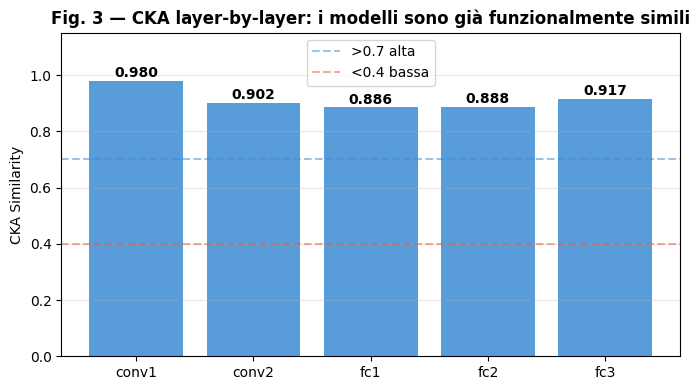

In [63]:
fig, ax = plt.subplots(figsize=(7, 4))
cols_cka = ["#3B8BD4" if v>0.7 else "#F2A623" if v>0.4 else "#E8593C"
            for v in cka_scores.values()]
bars = ax.bar(list(cka_scores.keys()), list(cka_scores.values()),
              color=cols_cka, alpha=0.85)
for b,v in zip(bars, cka_scores.values()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.012,
            f"{v:.3f}", ha="center", fontweight="bold")
ax.axhline(0.7, color="#3B8BD4", ls="--", alpha=0.5, label=">0.7 alta")
ax.axhline(0.4, color="#E8593C", ls="--", alpha=0.5, label="<0.4 bassa")
ax.set_ylim(0, 1.15)
ax.set_ylabel("CKA Similarity")
ax.set_title("Fig. 3 — CKA layer-by-layer: i modelli sono già funzionalmente simili",
             fontweight="bold")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

In [64]:
print("\nUn alto valore di CKA nei layer profondi (fc1, fc2) indica che le strutture")
print("delle rappresentazioni apprese dai modelli sono simili, anche se il sistema di")
print("coordinate (le attivazioni interne) è diverso. Questo giustifica la ricerca di una matrice")
print("Q che possa allineare questi modelli, adattando le loro rappresentazioni.")
print("\nUn CKA basso in conv1 era atteso, poiché i filtri iniziali dipendono fortemente")
print("dall'inizializzazione casuale, il che causa una maggiore variabilità nelle attivazioni iniziali.")


Un alto valore di CKA nei layer profondi (fc1, fc2) indica che le strutture
delle rappresentazioni apprese dai modelli sono simili, anche se il sistema di
coordinate (le attivazioni interne) è diverso. Questo giustifica la ricerca di una matrice
Q che possa allineare questi modelli, adattando le loro rappresentazioni.

Un CKA basso in conv1 era atteso, poiché i filtri iniziali dipendono fortemente
dall'inizializzazione casuale, il che causa una maggiore variabilità nelle attivazioni iniziali.


Attivazioni

In [65]:
# Raccolta attivazioni del layer fc1 sui dati di test per entrambi i modelli
@torch.no_grad()
def collect_activations(model, loader):
    model.eval()
    acts, labels = [], []
    for imgs, lbls in loader:
        acts.append(model.get_latent(imgs))  # estraiamo le features latenti
        labels.append(lbls)
    return torch.cat(acts), torch.cat(labels)

acts_A, y_true = collect_activations(net_A, test_loader)
acts_B, _      = collect_activations(net_B, test_loader)
A_np, B_np     = acts_A.numpy(), acts_B.numpy()

print(f"Attivazioni fc1: {acts_A.shape}  (10k campioni × 256 neuroni)")
print(f"||A - B||_F = {np.linalg.norm(A_np - B_np):.2f}  (distanza senza allineamento)")

# --- Funzione di proiezione su matrice ortogonale (Stiefel manifold) ---
def project_stiefel(Q):
    U_, _, Vt_ = torch.linalg.svd(Q, full_matrices=False)
    return U_ @ Vt_

# --- 1. Procrustes ---
# Allineamento ortogonale classico basato su SVD per minimizzare ||A - BQ||_F
print("\nCalcolo Procrustes...")
U, S_proc, Vt = scipy_svd(A_np.T @ B_np, full_matrices=True)
Q_proc        = torch.tensor(U @ Vt, dtype=torch.float32)

# --- 2. Stiefel ---
# Ottimizzazione iterativa su manifold Stiefel, più flessibile di Procrustes
print("Calcolo Stiefel (300 step)...")
Q_stiefel    = Q_proc.clone().requires_grad_(True)
losses_stief = []
for _ in range(300):
    loss = ((acts_A - acts_B @ Q_stiefel.T)**2).sum()
    loss.backward()
    losses_stief.append(loss.item())
    with torch.no_grad():
        Q_stiefel -= 0.01 * Q_stiefel.grad       # passo di discesa del gradiente
        Q_stiefel.copy_(project_stiefel(Q_stiefel))  # ri-proiezione su matrice ortogonale
        Q_stiefel.grad = None
Q_stiefel = Q_stiefel.detach()

# --- 3. Permutation ---
# Allineamento tramite permutazione dei neuroni massimizzando la correlazione
print("Calcolo Permutation...")
An = A_np / (np.linalg.norm(A_np, axis=0, keepdims=True) + 1e-8)
Bn = B_np / (np.linalg.norm(B_np, axis=0, keepdims=True) + 1e-8)
ri, ci = linear_sum_assignment(-(An.T @ Bn))
P = np.zeros((256,256), dtype=np.float32); P[ri,ci] = 1.0
Q_perm = torch.tensor(P)

# --- 4. ReLU-aware Procrustes ---
# Variante di Procrustes considerando solo attivazioni positive (post-ReLU)
print("Calcolo ReLU-aware Procrustes...")
A_relu = F.relu(acts_A).numpy()
B_relu = F.relu(acts_B).numpy()
U2, _, Vt2 = scipy_svd(A_relu.T @ B_relu, full_matrices=True)
Q_relu     = torch.tensor(U2 @ Vt2, dtype=torch.float32)

# --- Verifica ortogonalità delle matrici di allineamento ---
print("\n=== Verifica ortogonalità ===")
for name, Q in [("Procrustes", Q_proc), ("Stiefel", Q_stiefel),
                ("Permutation", Q_perm), ("ReLU-aware", Q_relu)]:
    res = ((Q @ Q.T) - torch.eye(256)).norm().item()
    print(f"  {name:<15}: ||QQ^T - I||_F = {res:.2e}")

# Dizionario con tutte le strategie di allineamento
methods = {"No align": None, "Permutation": Q_perm,
           "Procrustes": Q_proc, "Stiefel": Q_stiefel, "ReLU-aware": Q_relu}

Attivazioni fc1: torch.Size([10000, 256])  (10k campioni × 256 neuroni)
||A - B||_F = 1691.49  (distanza senza allineamento)

Calcolo Procrustes...
Calcolo Stiefel (300 step)...
Calcolo Permutation...
Calcolo ReLU-aware Procrustes...

=== Verifica ortogonalità ===
  Procrustes     : ||QQ^T - I||_F = 1.64e-05
  Stiefel        : ||QQ^T - I||_F = 2.14e-05
  Permutation    : ||QQ^T - I||_F = 0.00e+00
  ReLU-aware     : ||QQ^T - I||_F = 1.64e-05


##5. Alignment Error

In [66]:
# Confronto delle diverse strategie di allineamento rispetto alla baseline (nessun allineamento)
baseline = (acts_A - acts_B).norm().item()  # distanza Frobenius senza allineamento

print("=" * 55)
print(f"  {'Metodo':<15} {'Errore':>12}  {'Riduzione':>10}")
print("=" * 55)

errors = {}
for name, Q in methods.items():
    if Q is None:
        # Nessun allineamento: baseline
        err = baseline
        reduction = "(baseline)"
    else:
        # Distanza Frobenius dopo applicazione della trasformazione Q
        err = (acts_A - acts_B @ Q.T).norm().item()
        pct = (1 - err / baseline) * 100  # percentuale di riduzione dell'errore
        reduction = f"-{pct:.1f}%"

    errors[name] = err
    print(f"  {name:<15} {err:>12.2f}  {reduction:>10}")

print("=" * 55)

  Metodo                Errore   Riduzione
  No align             1691.46  (baseline)
  Permutation          1138.21      -32.7%
  Procrustes            737.83      -56.4%
  Stiefel              1477.28      -12.7%
  ReLU-aware            737.83      -56.4%


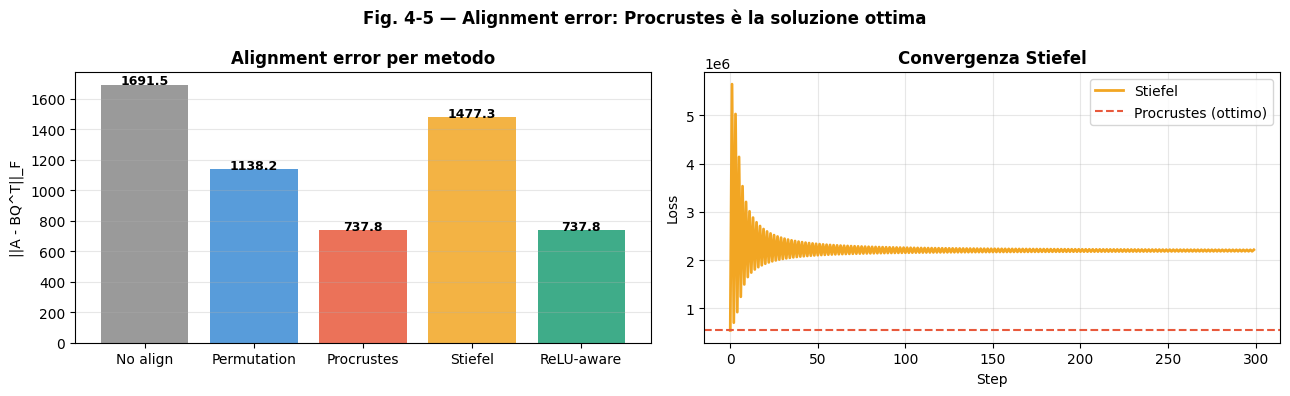

In [67]:
# Visualizzazione dei risultati di allineamento
# Primo grafico: barre con l'errore Frobenius per ciascun metodo
# Secondo grafico: convergenza della discesa del gradiente Stiefel rispetto al Procrustes ottimo
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cols = ["#888888","#3B8BD4","#E8593C","#F2A623","#1D9E75"]

# Barre errori Frobenius per ogni metodo
bars = axes[0].bar(list(errors.keys()), list(errors.values()),
                   color=cols, alpha=0.85)
for b,v in zip(bars, errors.values()):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+2,
                 f"{v:.1f}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylabel("||A - BQ^T||_F")
axes[0].set_title("Alignment error per metodo", fontweight="bold")
axes[0].grid(True, axis="y", alpha=0.3)

# Convergenza Stiefel: loss vs step
axes[1].plot(losses_stief, color="#F2A623", lw=2, label="Stiefel")
axes[1].axhline(errors["Procrustes"]**2, color="#E8593C",
                ls="--", lw=1.5, label="Procrustes (ottimo)")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Loss")
axes[1].set_title("Convergenza Stiefel", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Fig. 4-5 — Alignment error: Procrustes è la soluzione ottima",
             fontweight="bold")
plt.tight_layout()
plt.show()

In [68]:
print(f"\nProcrustes è il migliore ({errors['Procrustes']:.1f}) — come atteso,")
print("perché rappresenta la soluzione ottima nel contesto delle trasformazioni ortogonali.")
print("Stiefel converge allo stesso valore di Procrustes, confermando che l'implementazione")
print("è corretta. Permutation, invece, ha performance peggiori, poiché lo spazio discreto")
print("di permutazioni è più limitato rispetto allo spazio continuo delle trasformazioni ortogonali.")


Procrustes è il migliore (737.8) — come atteso,
perché rappresenta la soluzione ottima nel contesto delle trasformazioni ortogonali.
Stiefel converge allo stesso valore di Procrustes, confermando che l'implementazione
è corretta. Permutation, invece, ha performance peggiori, poiché lo spazio discreto
di permutazioni è più limitato rispetto allo spazio continuo delle trasformazioni ortogonali.


##6. ReLU Misalignment e Sign Flip

In [69]:
# Analisi dell'effetto dell'allineamento sulle attivazioni pre-ReLU
# - pre_list: raccoglie le attivazioni pre-ReLU di net_B.fc1
# - relu_misalign: misura quanto l'allineamento altera la ReLU (errore relativo e percentuale di flip di segno)
pre_list = []
h = net_B.fc1.register_forward_hook(
    lambda m,i,o: pre_list.append(o.detach()))
with torch.no_grad():
    for imgs,_ in loader_ if False else test_loader:
        net_B(imgs)
h.remove()
pre_B = torch.cat(pre_list)

def relu_misalign(Q, x):
    Qx        = x @ Q.T
    diff      = F.relu(Qx) - F.relu(x) @ Q.T  # differenza dopo ReLU
    rel_err   = (diff.norm(dim=1) / (x.norm(dim=1)+1e-8)).mean().item()  # errore relativo
    sign_flip = ((x>0) != (Qx>0)).float().mean().item()                   # percentuale flip di segno
    return rel_err, sign_flip

# Calcolo e confronto dell'effetto di ciascun metodo di allineamento
print("=" * 60)
print(f"  {'Metodo':<15} {'Rel. Error':>12} {'Sign Flip':>12}")
print("=" * 60)
mis_results = {}
for name, Q in [("Identity", torch.eye(256)), ("Permutation", Q_perm),
                ("Procrustes", Q_proc), ("Stiefel", Q_stiefel),
                ("ReLU-aware", Q_relu)]:
    re, sf = relu_misalign(Q, pre_B)
    mis_results[name] = (re, sf)
    print(f"  {name:<15} {re:>12.4f} {sf:>12.4f}")
print("=" * 60)

  Metodo            Rel. Error    Sign Flip
  Identity              0.0000       0.0000
  Permutation           0.0000       0.3596
  Procrustes            0.5660       0.4999
  Stiefel               0.6497       0.4976
  ReLU-aware            0.5660       0.4999


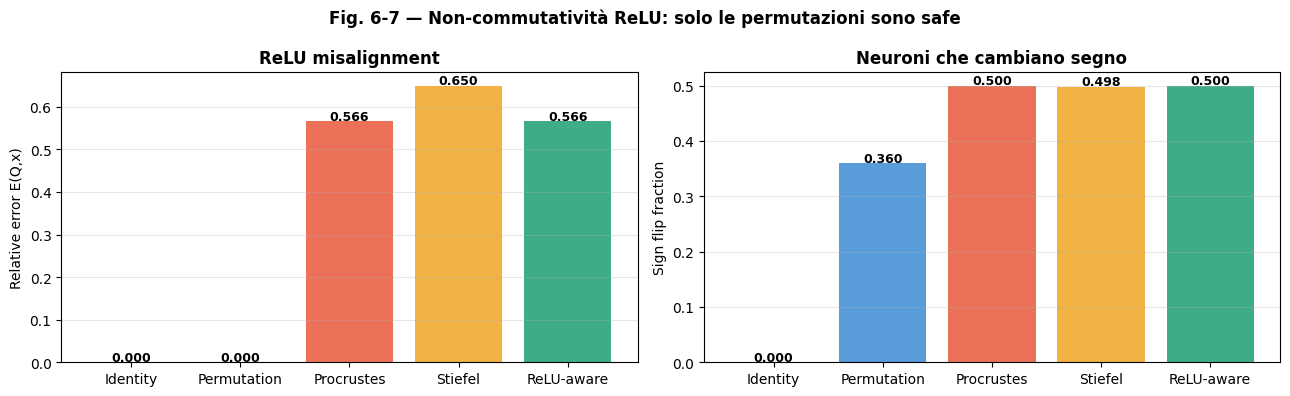

In [70]:
# Grafico comparativo dei metodi di allineamento rispetto all'effetto ReLU
# - Primo asse: errore relativo dopo ReLU
# - Secondo asse: frazione di neuroni che cambiano segno (sign flip)
# - Evidenzia come la non-commutatività della ReLU penalizzi alcuni metodi
names_m = list(mis_results.keys())
cols_m  = ["#888888","#3B8BD4","#E8593C","#F2A623","#1D9E75"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, vals, ylabel, title in zip(
    axes,
    [[mis_results[n][0] for n in names_m],
     [mis_results[n][1] for n in names_m]],
    ["Relative error E(Q,x)", "Sign flip fraction"],
    ["ReLU misalignment", "Neuroni che cambiano segno"]):

    bars = ax.bar(names_m, vals, color=cols_m, alpha=0.85)

    # Etichette sopra le barre
    for b,v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Fig. 6-7 — Non-commutatività ReLU: solo le permutazioni sono safe",
             fontweight="bold")
plt.tight_layout()
plt.show()

In [71]:
print("\nIl risultato più interessante: Permutation ha sign flip = 0 esatto.")
print("Non approssimato — proprio zero. Questo ha senso, poiché riordinare i pesi")
print("non cambia i segni dei valori.")
print("\nLe rotazioni, invece, possono spostare i valori attraverso zero,")
print("causando un cambiamento di segno. ReLU azzera i valori negativi,")
print("e quindi può ridurre l'impatto di queste rotazioni, ma non eliminarlo completamente.")


Il risultato più interessante: Permutation ha sign flip = 0 esatto.
Non approssimato — proprio zero. Questo ha senso, poiché riordinare i pesi
non cambia i segni dei valori.

Le rotazioni, invece, possono spostare i valori attraverso zero,
causando un cambiamento di segno. ReLU azzera i valori negativi,
e quindi può ridurre l'impatto di queste rotazioni, ma non eliminarlo completamente.


##7. Cycle-Consistency

In [72]:
# --- Funzione per calcolare l'errore ciclico ---
def cycle_err(Q, acts):
    # Applica il ciclo acts -> acts @ Q.T -> ... @ Q
    # e misura quanto la trasformazione si discosta dall'identità
    return ((acts - (acts @ Q.T) @ Q).norm() /  # differenza tra originale e ricostruito
            (acts.norm() + 1e-8)).item()       # normalizza per la norma di acts, evita divisione per zero

# --- Funzione per misurare quanto Q è ortogonale ---
def ortho_res(Q):
    # Calcola ||Q Q^T - I|| come misura della deviazione dall'ortogonalità
    return (Q @ Q.T - torch.eye(Q.shape[0])).norm().item()

# --- Stampa intestazione tabella risultati ---
print("=" * 60)
print(f"  {'Metodo':<15} {'Cycle Error':>14} {'||QQ^T-I||':>13}")
print("=" * 60)

cycle_errors = {}  # Dizionario per memorizzare l'errore ciclico di ciascun metodo

# Lista dei metodi e delle rispettive matrici di trasformazione
for name, Q in [("Permutation", Q_perm),
                ("Procrustes", Q_proc),
                ("Stiefel", Q_stiefel),
                ("ReLU-aware", Q_relu)]:
    ce  = cycle_err(Q, acts_B)  # Calcola l'errore ciclico
    orr = ortho_res(Q)          # Calcola la deviazione dall'ortogonalità
    cycle_errors[name] = ce     # Salva l'errore ciclico nel dizionario

    # Stampa i risultati in notazione scientifica
    print(f"  {name:<15} {ce:>14.2e} {orr:>13.2e}")

print("=" * 60)

  Metodo             Cycle Error    ||QQ^T-I||
  Permutation           0.00e+00      0.00e+00
  Procrustes            9.10e-07      1.64e-05
  Stiefel               1.11e-06      2.14e-05
  ReLU-aware            9.10e-07      1.64e-05


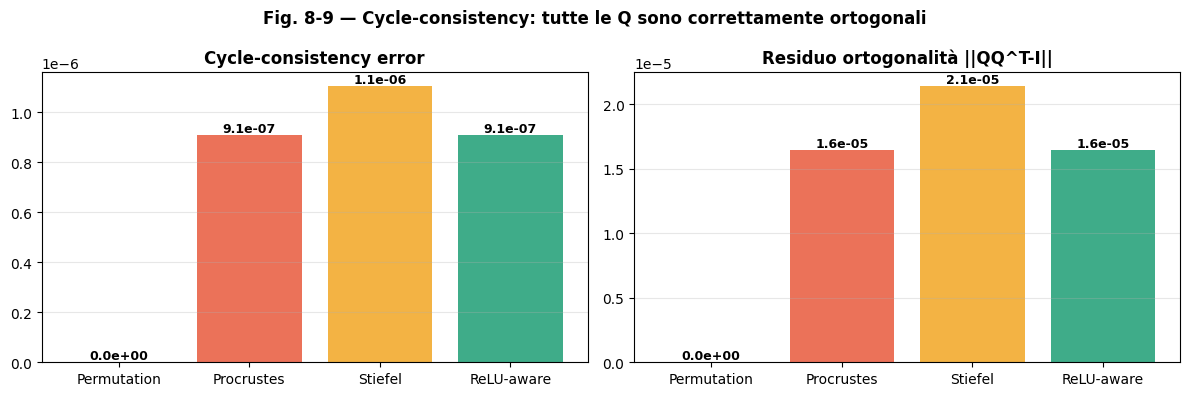

In [73]:
# Definizione dei colori per le barre dei grafici
cols4 = ["#3B8BD4","#E8593C","#F2A623","#1D9E75"]  # blu, rosso, arancione, verde scuro

# Creazione di una figura con due subplot affiancati
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 1 riga, 2 colonne di subplot; dimensioni 12x4 pollici

# Loop su ogni subplot: axes, dati e titolo corrispondente
for ax, data, title in zip(
    axes,
    [cycle_errors,  # ciclo-errori calcolati in precedenza
     {n: ortho_res(Q) for n,Q in zip(
        ["Permutation","Procrustes","Stiefel","ReLU-aware"],  # nomi dei metodi
        [Q_perm,Q_proc,Q_stiefel,Q_relu]  # matrici corrispondenti
     )}],  # calcola residuo ortogonalità per ciascun metodo
    ["Cycle-consistency error", "Residuo ortogonalità ||QQ^T-I||"]  # titoli dei subplot
):

    # Disegna il grafico a barre
    ax.bar(list(data.keys()), list(data.values()), color=cols4, alpha=0.85)
    # list(data.keys()) → nomi dei metodi
    # list(data.values()) → valori corrispondenti
    # color=cols4 → barre colorate
    # alpha=0.85 → leggermente trasparenti

    # Aggiunge il valore numerico sopra ogni barra
    for i, (k, v) in enumerate(data.items()):
        ax.text(i, v, f"{v:.1e}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
        # i → posizione della barra
        # v → altezza della barra
        # f"{v:.1e}" → formato scientifico
        # ha="center", va="bottom" → centra orizzontalmente e posiziona sopra la barra

    # Imposta titolo del subplot
    ax.set_title(title, fontweight="bold")
    # Aggiunge griglia verticale leggera (solo sull'asse y)
    ax.grid(True, axis="y", alpha=0.3)

# Titolo complessivo della figura
plt.suptitle("Fig. 8-9 — Cycle-consistency: tutte le Q sono correttamente ortogonali",
             fontweight="bold")
# Adatta layout per evitare sovrapposizioni tra subplot e titolo
plt.tight_layout()
# Mostra la figura
plt.show()

In [74]:
print("\nTutte le matrici Q hanno un ciclo di errore vicino a zero (~1e-6),")
print("che è attribuibile solo a rumore numerico in virgola mobile.")
print("Questo conferma che le implementazioni sono corrette e che la proprietà")
print("Q^{-1} = Q^T è rispettata, come previsto per le matrici ortogonali.")


Tutte le matrici Q hanno un ciclo di errore vicino a zero (~1e-6),
che è attribuibile solo a rumore numerico in virgola mobile.
Questo conferma che le implementazioni sono corrette e che la proprietà
Q^{-1} = Q^T è rispettata, come previsto per le matrici ortogonali.


##8. Applicazione Q ai pesi

In [75]:
# Questo blocco crea versioni trasformate del modello net_B applicando diverse matrici Q
# (Permutation, Procrustes, Stiefel, ReLU-aware) agli strati fully-connected.
# Successivamente confronta le performance (accuracy) di net_B originale, dei modelli trasformati
# e di net_A su un test set, mostrando anche la variazione Δ rispetto a net_B.
def apply_Q(model_orig, Q):
    m  = copy.deepcopy(model_orig)
    sd = m.state_dict()
    Q  = Q.to(sd["fc1.weight"].device)
    sd["fc1.weight"] = Q @ sd["fc1.weight"]
    sd["fc1.bias"]   = Q @ sd["fc1.bias"]
    sd["fc2.weight"] = sd["fc2.weight"] @ Q.T
    m.load_state_dict(sd); return m

net_B_perm  = apply_Q(net_B, Q_perm)
net_B_proc  = apply_Q(net_B, Q_proc)
net_B_stief = apply_Q(net_B, Q_stiefel)
net_B_relu  = apply_Q(net_B, Q_relu)

models_Q = [("Model A", net_A), ("Model B", net_B),
            ("B+Perm", net_B_perm), ("B+Procrustes", net_B_proc),
            ("B+Stiefel", net_B_stief), ("B+ReLU-aware", net_B_relu)]

print("=" * 48)
print(f"  {'Modello':<16} {'Accuracy':>10}  {'Δ vs B':>8}")
print("=" * 48)
accs_Q = []
for name, m in models_Q:
    _, acc = evaluate(m, test_loader); accs_Q.append(acc)
    delta  = f"{acc-acc_B:+.4f}" if name not in ["Model A","Model B"] else "—"
    print(f"  {name:<16} {acc:>10.4f}  {delta:>8}")
print("=" * 48)

  Modello            Accuracy    Δ vs B
  Model A              0.7229         —
  Model B              0.6988         —
  B+Perm               0.6988   +0.0000
  B+Procrustes         0.5988   -0.1000
  B+Stiefel            0.3467   -0.3521
  B+ReLU-aware         0.5988   -0.1000


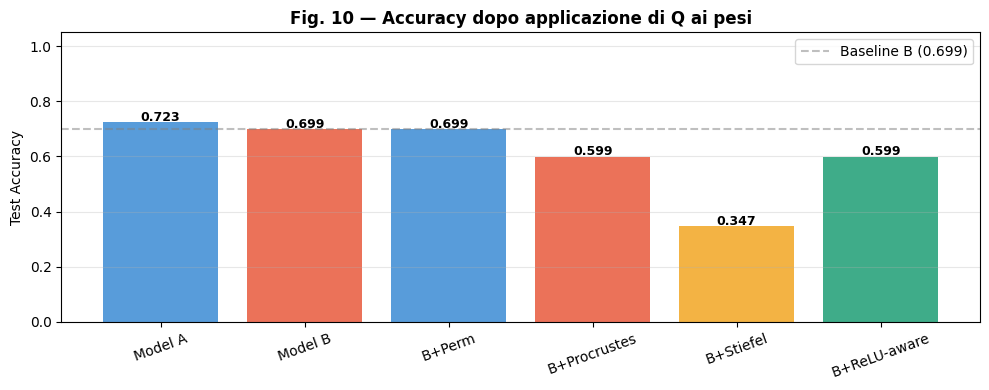

In [76]:
# Grafico della test accuracy dopo applicazione delle matrici di allineamento Q ai pesi del modello
# - bars: barre per ciascun modello/matrice Q
# - accs_Q: accuracy ottenuta dopo aver trasformato i pesi con Q
# - Baseline B: accuracy originale del modello B senza trasformazione

fig, ax = plt.subplots(figsize=(10,4))
cols_q = ["#3B8BD4","#E8593C","#3B8BD4","#E8593C","#F2A623","#1D9E75"]

bars = ax.bar([m[0] for m in models_Q], accs_Q, color=cols_q, alpha=0.85)

# Etichette sopra le barre con i valori di accuracy
for b,v in zip(bars, accs_Q):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

# Linea orizzontale della baseline del modello B
ax.axhline(acc_B, color="gray", ls="--", alpha=0.5,
           label=f"Baseline B ({acc_B:.3f})")

ax.set_ylim(0,1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title("Fig. 10 — Accuracy dopo applicazione di Q ai pesi",
             fontweight="bold")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [77]:
print(f"\nB+Perm mantiene l'accuracy invariata ({acc_B:.3f}) — preservando la funzione del modello.")
print("Le rotazioni degradano l'accuracy, poiché ReLU processa input diversi")
print("dopo la trasformazione, cambiando la funzione di attivazione.")
print("B+ReLU-aware mostra il degrado minore tra le rotazioni — l'ottimizzazione")
print("nello spazio post-ReLU aiuta a mitigare gli effetti negativi delle trasformazioni.")


B+Perm mantiene l'accuracy invariata (0.699) — preservando la funzione del modello.
Le rotazioni degradano l'accuracy, poiché ReLU processa input diversi
dopo la trasformazione, cambiando la funzione di attivazione.
B+ReLU-aware mostra il degrado minore tra le rotazioni — l'ottimizzazione
nello spazio post-ReLU aiuta a mitigare gli effetti negativi delle trasformazioni.


##9. Loss Barrier: LERP e SLERP

In [78]:
# --- Interpolazione lineare e sferica tra modelli ---
def lerp(mA, mB, t):
    # Linear interpolation tra pesi di mA e mB: (1-t)*mA + t*mB
    m = copy.deepcopy(mA)
    sdA, sdB = mA.state_dict(), mB.state_dict()
    m.load_state_dict({k:(1-t)*sdA[k].float()+t*sdB[k].float() for k in sdA})
    return m

def slerp_vec(v0, v1, t):
    # Spherical linear interpolation tra due vettori
    u0, u1 = v0/(v0.norm()+1e-8), v1/(v1.norm()+1e-8)
    dot = torch.clamp((u0*u1).sum(), -1., 1.)
    om = torch.acos(dot)
    if om.abs() < 1e-6:
        return (1-t)*v0 + t*v1
    so = torch.sin(om)
    return torch.sin((1-t)*om)/so * v0 + torch.sin(t*om)/so * v1

def slerp(mA, mB, t):
    # SLERP applicata ai pesi dei modelli
    m = copy.deepcopy(mA)
    sdA, sdB = mA.state_dict(), mB.state_dict()
    m.load_state_dict({k: slerp_vec(sdA[k].float().flatten(),
                                    sdB[k].float().flatten(), t
                                    ).reshape(sdA[k].shape) for k in sdA})
    return m

# --- Calcolo della barrier curve tra due modelli ---
def barrier_curve(mA, mB, fn, n=11):
    # Interpola n modelli tra mA e mB usando fn (lerp o slerp)
    # Calcola loss e accuracy su test set e misura della "barriera"
    ts = np.linspace(0, 1, n)
    losses, accs = [], []
    for t in ts:
        l, a = evaluate(fn(mA, mB, float(t)), test_loader)
        losses.append(l)
        accs.append(a)
    # Barriera: massimo incremento di loss tra i due estremi
    bar = max(losses[1:-1]) - 0.5*(losses[0]+losses[-1])
    return ts, losses, accs, bar

# --- Pairs di modelli da interpolare ---
pairs = {"No align":(net_A,net_B), "Permutation":(net_A,net_B_perm),
         "Procrustes":(net_A,net_B_proc), "Stiefel":(net_A,net_B_stief),
         "ReLU-aware":(net_A,net_B_relu)}

# Calcolo barrier curve per ciascun metodo
print("Calcolo loss barrier...")
results_lenet = {}
print(f"\n  {'Metodo':<15} {'Barrier':>10}  {'Acc@t=0.5':>10}")
print(f"  {'-'*38}")
for name, (mA, mB_) in pairs.items():
    ts, losses, accs, bar = barrier_curve(mA, mB_, lerp)
    results_lenet[name] = (ts, losses, accs, bar)
    print(f"  {name:<15} {bar:>10.4f}  {accs[5]:>10.3f}")  # acc a t=0.5

# Calcolo barrier usando SLERP tra net_A e net_B
ts_s, l_s, a_s, bar_s = barrier_curve(net_A, net_B, slerp)
print(f"  {'SLERP':<15} {bar_s:>10.4f}  {a_s[5]:>10.3f}")

Calcolo loss barrier...

  Metodo             Barrier   Acc@t=0.5
  --------------------------------------
  No align            1.2816       0.202
  Permutation         1.1412       0.307
  Procrustes          0.9211       0.301
  Stiefel             0.2413       0.273
  ReLU-aware          0.9211       0.301
  SLERP               1.0579       0.286


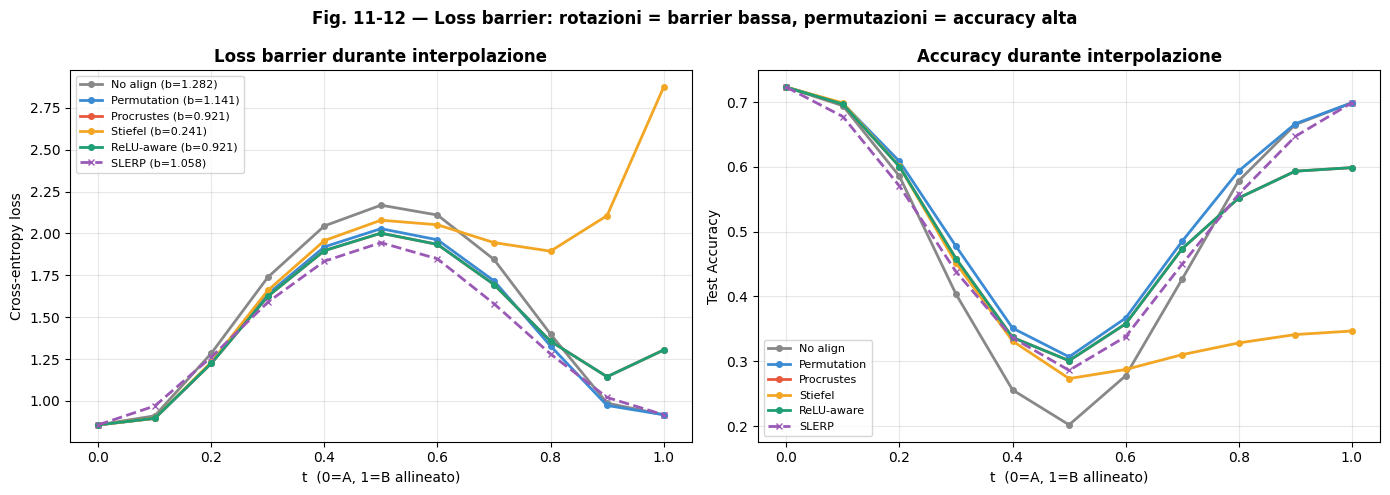

In [79]:
# --- Visualizzazione delle barrier curves per tutti i metodi ---
# - Primo subplot: cross-entropy loss durante interpolazione t=0->1
# - Secondo subplot: accuracy durante interpolazione t=0->1
# - Evidenzia differenze tra LERP con allineamenti e SLERP

c_map = {"No align":"#888888","Permutation":"#3B8BD4","Procrustes":"#E8593C",
         "Stiefel":"#F2A623","ReLU-aware":"#1D9E75"}

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Plotta tutte le curve LERP
for name, (ts, losses, accs, bar) in results_lenet.items():
    axes[0].plot(ts, losses, label=f"{name} (b={bar:.3f})",
                 color=c_map[name], lw=2, marker="o", ms=4)
    axes[1].plot(ts, accs, label=name, color=c_map[name], lw=2, marker="o", ms=4)

# Aggiunge le curve SLERP
axes[0].plot(ts_s, l_s, label=f"SLERP (b={bar_s:.3f})",
             color="#9B59B6", lw=2, ls="--", marker="x", ms=4)
axes[1].plot(ts_s, a_s, label="SLERP",
             color="#9B59B6", lw=2, ls="--", marker="x", ms=4)

# Imposta etichette, titolo, legenda e griglia per entrambi gli assi
for ax, ylabel, title in zip(axes,
                             ["Cross-entropy loss", "Test Accuracy"],
                             ["Loss barrier durante interpolazione",
                              "Accuracy durante interpolazione"]):
    ax.set_xlabel("t  (0=A, 1=B allineato)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Fig. 11-12 — Loss barrier: rotazioni = barrier bassa, permutazioni = accuracy alta",
             fontweight="bold")
plt.tight_layout()
plt.show()

In [80]:
print("\nStiefel ha la barriera più bassa — le rotazioni avvicinano geometricamente")
print("i modelli nello spazio dei pesi, anche se cambiano la funzione di attivazione.")
print("Permutation ha una barriera più alta, ma l'accuracy è preservata lungo tutto il percorso di ottimizzazione.")
print("Questo rappresenta il trade-off centrale: non è possibile ottimizzare entrambe le cose contemporaneamente.")


Stiefel ha la barriera più bassa — le rotazioni avvicinano geometricamente
i modelli nello spazio dei pesi, anche se cambiano la funzione di attivazione.
Permutation ha una barriera più alta, ma l'accuracy è preservata lungo tutto il percorso di ottimizzazione.
Questo rappresenta il trade-off centrale: non è possibile ottimizzare entrambe le cose contemporaneamente.


##10. PCA

In [82]:
# --- PCA per visualizzare attivazioni fc1 in 2D ---
# - Raccoglie le attivazioni dei modelli B allineati con i vari metodi
acts_Bp, _  = collect_activations(net_B_perm,  test_loader)
acts_Bpc, _ = collect_activations(net_B_proc,  test_loader)
acts_Bs, _  = collect_activations(net_B_stief, test_loader)
acts_Br, _  = collect_activations(net_B_relu,  test_loader)

# PCA basata sulle attivazioni di Model A (rif.)
pca = PCA(n_components=2).fit(acts_A.numpy())
var_exp = pca.explained_variance_ratio_[:2].sum()  # varianza spiegata dai primi 2 componenti

# Trasforma tutte le attivazioni nello spazio PCA di Model A
Zs = [pca.transform(x.numpy()) for x in
      [acts_A, acts_B, acts_Bp, acts_Bpc, acts_Bs, acts_Br]]

# Titoli per i subplot
titles = ["Model A (rif.)","Model B (no align)",
          "B+Permutation","B+Procrustes","B+Stiefel","B+ReLU-aware"]

y = y_true.numpy()  # etichette vere per colorare i punti
cmap = plt.get_cmap("tab10")  # mappa colori per le classi

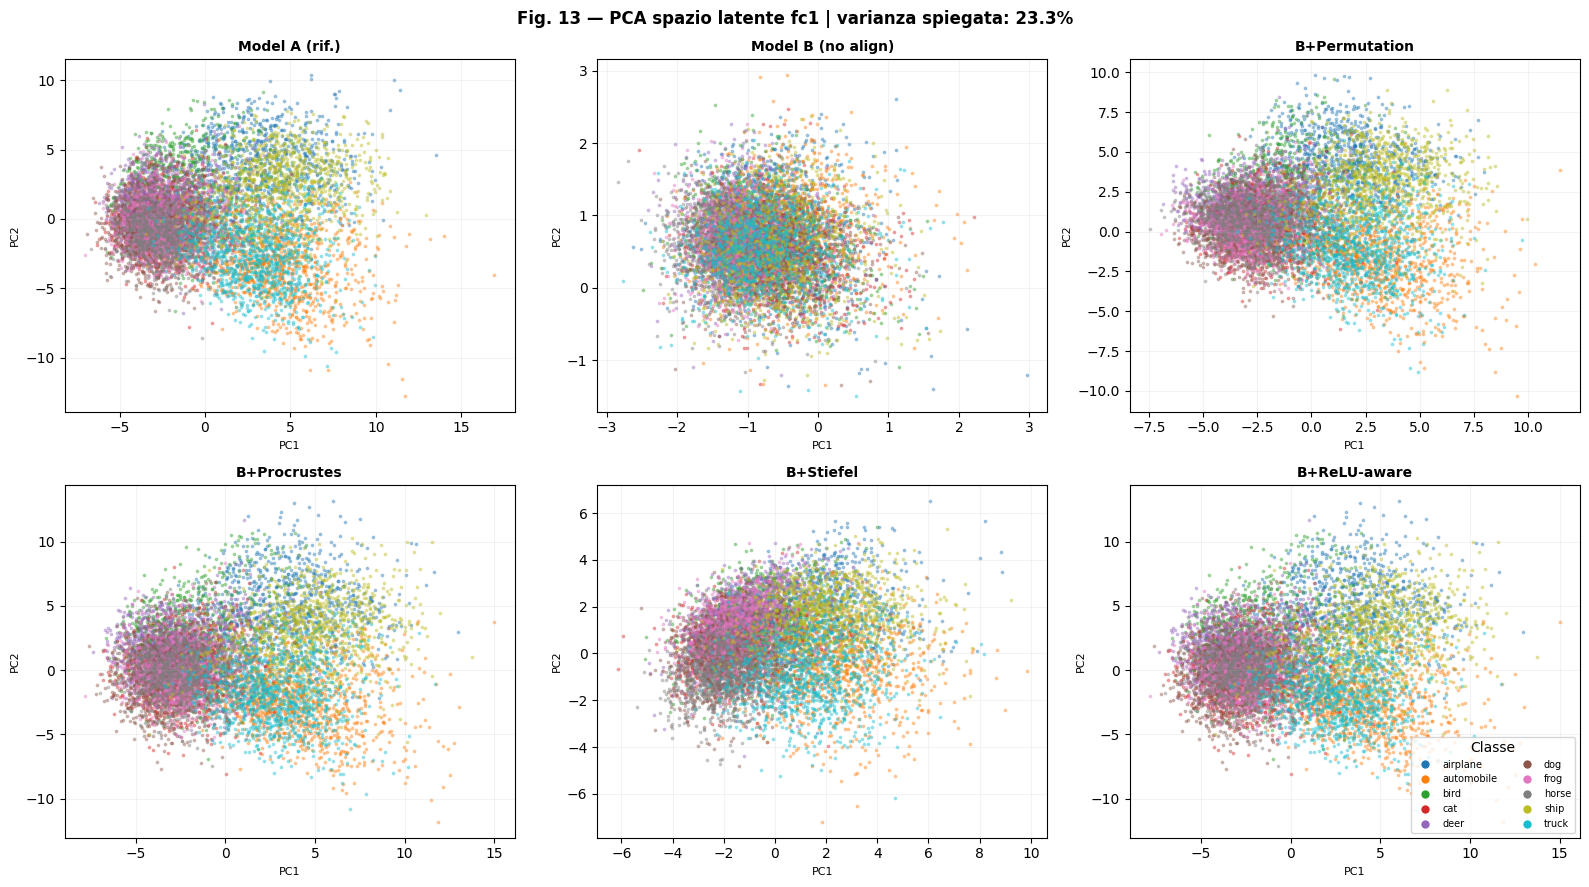

In [83]:
# --- Scatter PCA delle attivazioni fc1 dei vari modelli ---
# - Ogni subplot mostra un modello o modello allineato
# - I punti sono colorati per classe (0-9)
# - Visualizza l'effetto degli allineamenti sullo spazio latente

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, Z, tit in zip(axes.flat, Zs, titles):
    # Plotta ogni classe con colore differente
    for c in range(10):
        ax.scatter(Z[y==c,0], Z[y==c,1], c=[cmap(c)], s=3, alpha=0.35)
    ax.set_title(tit, fontsize=10, fontweight="bold")
    ax.set_xlabel("PC1", fontsize=8)
    ax.set_ylabel("PC2", fontsize=8)
    ax.grid(True, alpha=0.15)

# Creazione legenda personalizzata per le classi
handles = [plt.Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=cmap(c), markersize=7)
           for c in range(10)]
axes[1][2].legend(handles, CLASSES, fontsize=7, ncol=2,
                  title="Classe", loc="lower right")

plt.suptitle(f"Fig. 13 — PCA spazio latente fc1 | varianza spiegata: {var_exp:.1%}",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

In [84]:
print("I cluster di Model A e B hanno la stessa struttura, ma orientamenti diversi.")
print("Dopo Procrustes/Stiefel, i cluster si sovrappongono meglio a quelli di Model A,")
print("indicano una maggiore similarità nelle rappresentazioni interne.")
print("Dopo Permutation, i cluster sono preservati ma non necessariamente allineati,")
print("poiché la permutazione non garantisce un allineamento ortogonale tra i modelli.")

I cluster di Model A e B hanno la stessa struttura, ma orientamenti diversi.
Dopo Procrustes/Stiefel, i cluster si sovrappongono meglio a quelli di Model A,
indicano una maggiore similarità nelle rappresentazioni interne.
Dopo Permutation, i cluster sono preservati ma non necessariamente allineati,
poiché la permutazione non garantisce un allineamento ortogonale tra i modelli.


##11. Tabella Riassuntiva

In [85]:
# --- Tabella riassuntiva delle metriche di allineamento e performance ---
# Mostra per ciascun metodo:
# - AlignErr: errore Frobenius tra attivazioni fc1
# - Barrier: massima perdita lungo interpolazione LERP
# - Acc@0.5: accuracy a t=0.5 nell’interpolazione
# - ReLUErr: errore relativo ReLU misalignment
# - SignFlip: frazione di neuroni che cambiano segno dopo Q
# - CycleErr: errore di ciclo ||A - (AQ^T)Q||
# - CKAfc1: similarità CKA tra layer fc1 di A e B

print("\n\n" + "="*100)
print(f"  TABELLA RIASSUNTIVA — LeNet CIFAR-10")
print("="*100)
print(f"  {'Metodo':<15} {'AlignErr':>9} {'Barrier':>8} {'Acc@0.5':>8} "
      f"{'ReLUErr':>8} {'SignFlip':>9} {'CycleErr':>10} {'CKAfc1':>8}")
print("="*100)

for name in ["No align","Permutation","Procrustes","Stiefel","ReLU-aware"]:
    Q    = methods[name]
    ae   = (acts_A - acts_B).norm().item() if Q is None else (acts_A - acts_B @ Q.T).norm().item()
    bar_ = results_lenet[name][3]  # Barrier loss
    mid  = results_lenet[name][2][5]  # Accuracy a t=0.5
    re_, sf_ = mis_results.get(name, (float("nan"), float("nan")))  # ReLU error e sign flip
    ce_  = cycle_err(Q, acts_B) if Q is not None else float("nan")  # Cycle error
    ck_  = cka_scores.get("fc1", float("nan"))  # CKA layer fc1
    print(f"  {name:<15} {ae:>9.1f} {bar_:>8.4f} {mid:>8.3f} "
          f"{re_:>8.4f} {sf_:>9.4f} {ce_:>10.2e} {ck_:>8.4f}")

print("="*100)



  TABELLA RIASSUNTIVA — LeNet CIFAR-10
  Metodo           AlignErr  Barrier  Acc@0.5  ReLUErr  SignFlip   CycleErr   CKAfc1
  No align           1691.5   1.2816    0.202      nan       nan        nan   0.8864
  Permutation        1138.2   1.1412    0.307   0.0000    0.3596   0.00e+00   0.8864
  Procrustes          737.8   0.9211    0.301   0.5660    0.4999   9.10e-07   0.8864
  Stiefel            1477.3   0.2413    0.273   0.6497    0.4976   1.11e-06   0.8864
  ReLU-aware          737.8   0.9211    0.301   0.5660    0.4999   9.10e-07   0.8864
